# Example: length and readability analysis

_This notebook builds on the quickstart guide. If you're new to Python/Jupyter and haven't read the quickstart yet, we recommend starting there._

**What is this?**
- This notebook features a basic analysis of agreement length and readability across time.
  
**Prerequisites**
- Run `pip install requests pandas seaborn matplotlib numpy textstat`
  - This will install `requests`, `pandas`, `seaborn`, `matplotlib`, `numpy`, and `textstat` (if not already installed)
- Obtain an API key from [pandects.org](https://pandects.org) and export it as `PANDECTS_API_KEY`

## Imports and setup

In [1]:
import json
import os
import re
import time
from collections import Counter
from pathlib import Path
import xml.dom.minidom
import xml.etree.ElementTree as ET
import textstat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# Configuration
API_BASE_URL = "https://api.pandects.org"
API_KEY = os.getenv("PANDECTS_API_KEY")

if not API_KEY:
    raise RuntimeError(
        "Missing PANDECTS_API_KEY. Export your key (starts with pdcts_) and re-run this cell."
    )

session = requests.Session()
session.headers.update({"Accept": "application/json", "X-API-Key": API_KEY})

retry = Retry(
    total=5,
    connect=5,
    read=5,
    status=5,
    backoff_factor=1.5,
    status_forcelist=(429, 500, 502, 503, 504),
    allowed_methods=frozenset(["GET"]),
    respect_retry_after_header=True,
)
adapter = HTTPAdapter(max_retries=retry, pool_connections=4, pool_maxsize=4)
session.mount("https://", adapter)
session.mount("http://", adapter)


## Agreement length analysis

### Download
Fetch agreements in resumable batches from `GET /v1/agreements` (`include_xml=true`) using the cursor returned by `next_cursor`, checkpoint progress under `examples/.cache/`, and compute length features immediately.


In [3]:
WORD_RE = re.compile(r"[A-Za-z0-9']+")
WS_RE = re.compile(r"\s+")

SCHEMA_ROOT_TAG = "document"
SCHEMA_METADATA_TAG = "metadata"
SCHEMA_FRONT_TAG = "frontMatter"
SCHEMA_TOC_TAG = "tableOfContents"
SCHEMA_BODY_TAG = "body"
SCHEMA_SIG_TAG = "sigPages"
SCHEMA_BACK_TAG = "backMatter"

ALLOWED_ROOT_CHILD_TAGS = {
    SCHEMA_METADATA_TAG,
    SCHEMA_FRONT_TAG,
    SCHEMA_TOC_TAG,
    SCHEMA_BODY_TAG,
    SCHEMA_SIG_TAG,
    SCHEMA_BACK_TAG,
}


def local_name(tag: str) -> str:
    return tag.rsplit("}", 1)[-1]


def count_words(text: str | None) -> int:
    if not text:
        return 0
    return len(WORD_RE.findall(text))


def count_words_in_element(elem: ET.Element) -> int:
    total = count_words(elem.text)
    for child in elem:
        total += count_words_in_element(child)
        total += count_words(child.tail)
    return total


def get_unique_root_child(root: ET.Element, child_tag: str) -> ET.Element | None:
    matching = [child for child in root if local_name(child.tag) == child_tag]
    if len(matching) > 1:
        raise ValueError(f"Invalid XML: multiple <{child_tag}> containers.")
    return matching[0] if matching else None


def body_word_stats(body_elem: ET.Element) -> tuple[int, str, list[int]]:
    body_text_parts: list[str] = []
    section_word_counts: list[int] = []

    def rec(elem: ET.Element) -> int:
        total = count_words(elem.text)
        if elem.text:
            body_text_parts.append(elem.text)

        for child in elem:
            total += rec(child)
            total += count_words(child.tail)
            if child.tail:
                body_text_parts.append(child.tail)

        if local_name(elem.tag) == "section":
            section_word_counts.append(total)
        return total

    body_words = rec(body_elem)
    body_text = WS_RE.sub(" ", " ".join(body_text_parts)).strip()
    return body_words, body_text, section_word_counts


def agreement_word_counts(xml: str) -> dict[str, int | float | None]:
    root = ET.fromstring(xml)

    if local_name(root.tag) != SCHEMA_ROOT_TAG:
        raise ValueError(
            f"Invalid XML: expected <{SCHEMA_ROOT_TAG}> root, found <{local_name(root.tag)}>."
        )

    for child in root:
        child_tag = local_name(child.tag)
        if child_tag not in ALLOWED_ROOT_CHILD_TAGS:
            raise ValueError(f"Invalid XML: unexpected top-level tag <{child_tag}>.")

    front_elem = get_unique_root_child(root, SCHEMA_FRONT_TAG)
    toc_elem = get_unique_root_child(root, SCHEMA_TOC_TAG)
    body_elem = get_unique_root_child(root, SCHEMA_BODY_TAG)
    back_elem = get_unique_root_child(root, SCHEMA_BACK_TAG)
    _ = get_unique_root_child(root, SCHEMA_SIG_TAG)  # Signature pages intentionally excluded

    front_words = count_words_in_element(front_elem) if front_elem is not None else 0
    toc_words = count_words_in_element(toc_elem) if toc_elem is not None else 0
    front_toc_words = front_words + toc_words
    body_words = 0
    body_text = ""
    body_section_word_counts: list[int] = []
    if body_elem is not None:
        body_words, body_text, body_section_word_counts = body_word_stats(body_elem)
    back_words = count_words_in_element(back_elem) if back_elem is not None else 0

    total_no_sig_words = front_toc_words + body_words + back_words

    # Readability: BODY ONLY, computed from flattened text (all XML tags stripped)
    fk_grade_body: float | None = None
    if body_words >= 30 and body_elem is not None:
        try:
            fk_grade_body = float(textstat.flesch_kincaid_grade(body_text))
        except Exception:
            fk_grade_body = None

    section_count_body = len(body_section_word_counts)
    avg_words_per_section_body: float | None = None
    min_words_per_section_body: int | None = None
    max_words_per_section_body: int | None = None
    if section_count_body > 0:
        avg_words_per_section_body = float(np.mean(body_section_word_counts))
        min_words_per_section_body = int(min(body_section_word_counts))
        max_words_per_section_body = int(max(body_section_word_counts))

    return {
        "word_count_front_toc": front_toc_words,
        "word_count_body": body_words,
        "word_count_back": back_words,
        "word_count_total_no_sig": total_no_sig_words,
        "flesch_kincaid_grade_body": fk_grade_body,
        "section_count_body": section_count_body,
        "avg_words_per_section_body": avg_words_per_section_body,
        "min_words_per_section_body": min_words_per_section_body,
        "max_words_per_section_body": max_words_per_section_body,
    }


CACHE_DIR = Path("examples/.cache")
ROWS_CACHE_PATH = CACHE_DIR / "pandects_api_agreement_attributes_rows.jsonl"
PROGRESS_CACHE_PATH = CACHE_DIR / "pandects_api_agreement_attributes_progress.json"
RESET_CACHE = os.getenv("PANDECTS_RESET_AGREEMENT_CACHE") == "1"

page_size = int(os.getenv("PANDECTS_PAGE_SIZE", "25"))
if page_size < 1 or page_size > 100:
    raise ValueError("PANDECTS_PAGE_SIZE must be between 1 and 100.")

request_pause_s = float(os.getenv("PANDECTS_REQUEST_PAUSE_S", "0.1"))
request_timeout_s = (10, int(os.getenv("PANDECTS_READ_TIMEOUT_S", "180")))
progress_every = 5
max_request_attempts = 5


def reset_cache_files() -> None:
    for path in (ROWS_CACHE_PATH, PROGRESS_CACHE_PATH):
        if path.exists():
            path.unlink()


def load_cached_rows() -> list[dict[str, object]]:
    if not ROWS_CACHE_PATH.exists():
        return []

    rows: list[dict[str, object]] = []
    with ROWS_CACHE_PATH.open() as fh:
        for line in fh:
            stripped = line.strip()
            if not stripped:
                continue
            rows.append(json.loads(stripped))
    return rows


def append_cached_rows(rows: list[dict[str, object]]) -> None:
    if not rows:
        return

    with ROWS_CACHE_PATH.open("a") as fh:
        for row in rows:
            fh.write(json.dumps(row))
            fh.write("\n")


def load_progress() -> dict[str, object]:
    if not PROGRESS_CACHE_PATH.exists():
        return {}
    return json.loads(PROGRESS_CACHE_PATH.read_text())


def save_progress(*, cursor: str | None, batch_num: int, completed: bool, access_tier: str | None) -> None:
    PROGRESS_CACHE_PATH.write_text(
        json.dumps(
            {
                "cursor": cursor,
                "batch_num": batch_num,
                "completed": completed,
                "access_tier": access_tier,
            }
        )
    )


CACHE_DIR.mkdir(parents=True, exist_ok=True)
if RESET_CACHE:
    reset_cache_files()

progress = load_progress()
agreement_rows = load_cached_rows()
seen_agreement_ids = {
    row["agreement_uuid"]
    for row in agreement_rows
    if isinstance(row.get("agreement_uuid"), str)
}

cursor = progress.get("cursor")
if cursor is not None and not isinstance(cursor, str):
    raise RuntimeError("Invalid cache progress: cursor must be a string or null.")

batch_num = int(progress.get("batch_num", 0))
completed = bool(progress.get("completed", False))
access_tier = progress.get("access_tier")
if access_tier is not None and not isinstance(access_tier, str):
    raise RuntimeError("Invalid cache progress: access_tier must be a string or null.")

if agreement_rows:
    cache_state = "completed" if completed else "partial"
    print(f"Loaded {len(agreement_rows)} agreements from {cache_state} cache.")

start_time = time.time()

if not completed:
    while True:
        params = {
            "page_size": page_size,
            "include_xml": True,
        }
        if cursor:
            params["cursor"] = cursor

        payload = None
        for attempt in range(1, max_request_attempts + 1):
            try:
                r = session.get(
                    f"{API_BASE_URL}/v1/agreements",
                    params=params,
                    timeout=request_timeout_s,
                )
                r.raise_for_status()
                payload = r.json()
                break
            except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError) as exc:
                if attempt == max_request_attempts:
                    raise
                backoff_s = min(2 ** (attempt - 1), 30)
                print(
                    f"Request attempt {attempt}/{max_request_attempts} failed ({type(exc).__name__}); retrying in {backoff_s}s."
                )
                time.sleep(backoff_s)

        if payload is None:
            raise RuntimeError("Expected agreements payload after retries, got none.")

        batch = payload.get("results", [])
        batch_num += 1
        new_rows: list[dict[str, object]] = []

        for agreement in batch:
            agreement_uuid = agreement.get("agreement_uuid")
            xml = agreement.get("xml")

            if not isinstance(agreement_uuid, str) or not agreement_uuid:
                raise RuntimeError("Invalid agreements payload: missing agreement_uuid.")
            if not isinstance(xml, str) or not xml:
                raise RuntimeError(
                    "Invalid agreements payload: xml is missing. Ensure include_xml=true and authenticated access."
                )
            if agreement_uuid in seen_agreement_ids:
                continue

            counts = agreement_word_counts(xml)
            new_rows.append(
                {
                    "agreement_uuid": agreement_uuid,
                    "year": agreement.get("year"),
                    "acquirer": agreement.get("acquirer"),
                    "target": agreement.get("target"),
                    "deal_type": agreement.get("deal_type"),
                    **counts,
                }
            )
            seen_agreement_ids.add(agreement_uuid)

        agreement_rows.extend(new_rows)
        append_cached_rows(new_rows)

        has_next = bool(payload.get("has_next"))
        next_cursor = payload.get("next_cursor")
        if has_next and (not isinstance(next_cursor, str) or not next_cursor):
            raise RuntimeError("Invalid agreements payload: has_next=true but next_cursor missing.")

        cursor = next_cursor if has_next else None
        access_tier = payload.get("access", {}).get("tier")
        if access_tier is not None and not isinstance(access_tier, str):
            raise RuntimeError("Invalid agreements payload: access tier must be a string or null.")

        save_progress(
            cursor=cursor,
            batch_num=batch_num,
            completed=not has_next,
            access_tier=access_tier,
        )

        if batch_num % progress_every == 0 or not has_next:
            elapsed = time.time() - start_time
            print(
                f"Progress: batch {batch_num} | batch_size={len(batch)} | agreements={len(agreement_rows)} | elapsed={elapsed:.1f}s"
            )

        if not has_next:
            completed = True
            break

        time.sleep(request_pause_s)
else:
    print("Using completed on-disk cache. Set PANDECTS_RESET_AGREEMENT_CACHE=1 to refetch.")

elapsed_total = time.time() - start_time
print(f"Returned agreements: {len(agreement_rows)}")
print(f"Access tier: {access_tier}")
print(f"Total download time: {elapsed_total:.1f}s")

if not agreement_rows:
    raise RuntimeError("No agreements returned by /v1/agreements.")

Loaded 5200 agreements from partial cache.
Progress: batch 210 | batch_size=25 | agreements=5250 | elapsed=196.2s
Progress: batch 215 | batch_size=25 | agreements=5375 | elapsed=702.3s
Progress: batch 220 | batch_size=25 | agreements=5500 | elapsed=1155.5s
Progress: batch 225 | batch_size=25 | agreements=5625 | elapsed=1577.6s
Progress: batch 230 | batch_size=25 | agreements=5750 | elapsed=1971.0s
Progress: batch 235 | batch_size=25 | agreements=5875 | elapsed=2341.6s
Progress: batch 240 | batch_size=25 | agreements=6000 | elapsed=2682.4s
Progress: batch 245 | batch_size=25 | agreements=6125 | elapsed=3100.5s
Progress: batch 250 | batch_size=25 | agreements=6250 | elapsed=3398.4s
Progress: batch 255 | batch_size=25 | agreements=6375 | elapsed=3680.3s
Progress: batch 260 | batch_size=25 | agreements=6500 | elapsed=3937.8s
Progress: batch 265 | batch_size=25 | agreements=6625 | elapsed=4170.1s
Progress: batch 270 | batch_size=25 | agreements=6750 | elapsed=4378.1s
Progress: batch 275 | b

In [4]:
df = pd.DataFrame(agreement_rows)
df.head(1)


,agreement_uuid,year,acquirer,target,deal_type,word_count_front_toc,word_count_body,word_count_back,word_count_total_no_sig,flesch_kincaid_grade_body,section_count_body,avg_words_per_section_body,min_words_per_section_body,max_words_per_section_body
0,000d3478-d4a7-5d5f-a800-fdc98f229434,2025,FERRERO INTERNATIONAL S.A.,WK KELLOGG CO,merger,797,56293,0,57090,26.315699,103,538.92233,41,8253


In [5]:
# Standardize numeric columns used in analysis
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)


In [6]:
# Map deal type codes to display labels
deal_type_map = {
    "merger": "Merger",
    "stock_acquisition": "Stock acquisition",
    "asset_acquisition": "Asset acquisition",
    "membership_interest_purchase": "Membership interest",
    "tender_offer": "Tender offer",
}

df["deal_type"] = df["deal_type"].map(deal_type_map).fillna("Other / unknown")


In [7]:
df.head()

,agreement_uuid,year,acquirer,target,deal_type,word_count_front_toc,word_count_body,word_count_back,word_count_total_no_sig,flesch_kincaid_grade_body,section_count_body,avg_words_per_section_body,min_words_per_section_body,max_words_per_section_body
0,000d3478-d4a7-5d5f-a800-fdc98f229434,2025,FERRERO INTERNATIONAL S.A.,WK KELLOGG CO,Merger,797,56293,0,57090,26.315699,103,538.922330,41,8253
1,0019e1ac-3adc-5cd5-a561-1c409b7d87f8,2018,"Illumina, Inc.","Pacific Biosciences of California, Inc.",Merger,756,40833,0,41589,25.688343,90,447.988889,22,5204
2,0019e6f4-52ba-51f0-aa03-b46aa83907aa,2008,NYSE Euronext,"Wombat Financial Software, Inc.",Stock acquisition,948,51563,0,52511,24.180529,100,509.090000,18,5324
3,00247e5c-8834-515c-a8a7-f25e2d5d3662,2015,Olin Corp.,The Dow Chemical Co. /Chlor-Alkali & Derivativ...,Merger,824,44799,0,45623,24.682295,95,463.305263,13,6263
4,002969fd-d728-5efa-9609-4b729de457b6,2022,"Shutterstock, Inc.","Pond5, Inc.",Merger,958,56088,0,57046,24.340879,112,496.589286,31,10037


### Basic sample overview

#### 1. Simple counts

In [8]:
print("Top acquirers:")
for name, n in df["acquirer"].value_counts().head(5).items():
    print(f"- {name} ({n})")

print("\nTop years:")
for year, n in df["year"].value_counts().head(5).items():
    print(f"- {year} ({n})")


Top acquirers:
- Oracle Corp. (18)
- International Business Machines Corp. (13)
- Abbott Laboratories (12)
- Pfizer Inc. (12)
- Nuance Communications, Inc. (12)

Top years:
- 2021 (615)
- 2022 (448)
- 2007 (445)
- 2017 (429)
- 2018 (418)


#### 2. Number of deals by year

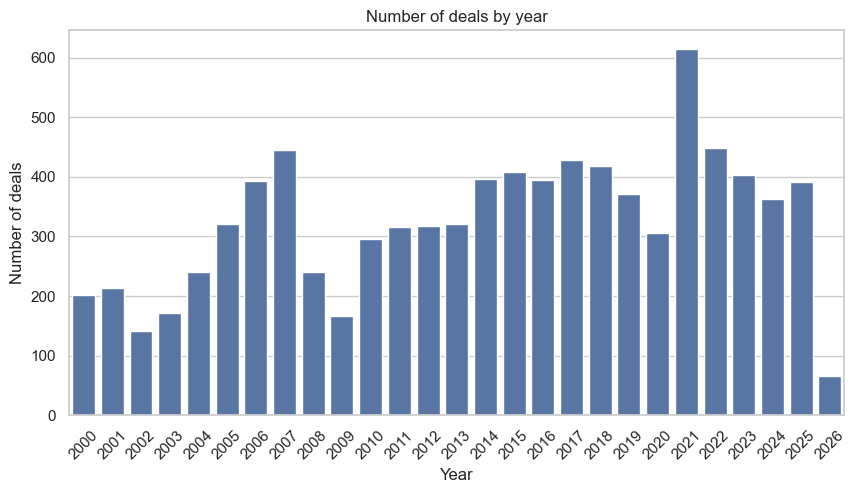

In [9]:
counts = df.groupby("year").size().reset_index(name="n_deals").sort_values("year")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=counts, x=counts["year"].astype(int).astype(str), y="n_deals")
ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year")
_ = plt.xticks(rotation=45)


#### 3. Number of deals by year (stacked by deal type)

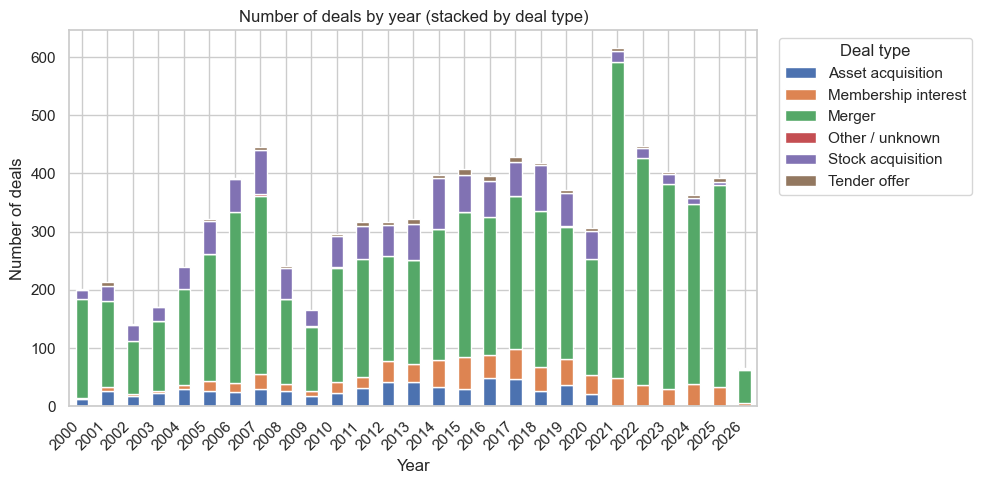

In [10]:
counts = (
    df.groupby(["year", "deal_type"])
      .size()
      .reset_index(name="n_deals")
)

wide = (
    counts.pivot(index="year", columns="deal_type", values="n_deals")
          .fillna(0)
          .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
wide.plot(kind="bar", stacked=True, ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Number of deals")
ax.set_title("Number of deals by year (stacked by deal type)")
ax.set_xticklabels(wide.index.astype(int).astype(str), rotation=45, ha="right")

ax.legend(title="Deal type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [11]:
df.head()

,agreement_uuid,year,acquirer,target,deal_type,word_count_front_toc,word_count_body,word_count_back,word_count_total_no_sig,flesch_kincaid_grade_body,section_count_body,avg_words_per_section_body,min_words_per_section_body,max_words_per_section_body
0,000d3478-d4a7-5d5f-a800-fdc98f229434,2025,FERRERO INTERNATIONAL S.A.,WK KELLOGG CO,Merger,797,56293,0,57090,26.315699,103,538.922330,41,8253
1,0019e1ac-3adc-5cd5-a561-1c409b7d87f8,2018,"Illumina, Inc.","Pacific Biosciences of California, Inc.",Merger,756,40833,0,41589,25.688343,90,447.988889,22,5204
2,0019e6f4-52ba-51f0-aa03-b46aa83907aa,2008,NYSE Euronext,"Wombat Financial Software, Inc.",Stock acquisition,948,51563,0,52511,24.180529,100,509.090000,18,5324
3,00247e5c-8834-515c-a8a7-f25e2d5d3662,2015,Olin Corp.,The Dow Chemical Co. /Chlor-Alkali & Derivativ...,Merger,824,44799,0,45623,24.682295,95,463.305263,13,6263
4,002969fd-d728-5efa-9609-4b729de457b6,2022,"Shutterstock, Inc.","Pond5, Inc.",Merger,958,56088,0,57046,24.340879,112,496.589286,31,10037


### Readability analysis

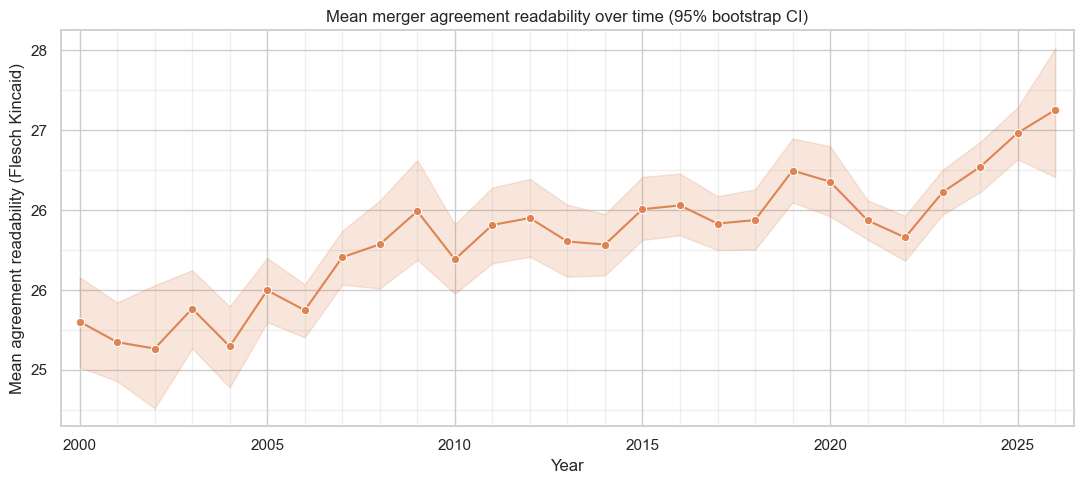

In [12]:
# mergers only
merger_df = df[df["deal_type"] == "Merger"].copy()
merger_df = merger_df.dropna(subset=["year", "flesch_kincaid_grade_body"])
if merger_df.empty:
    raise RuntimeError("No merger agreements found in this sample.")

merger_df["year"] = merger_df["year"].astype(int)

# yearly mean readability + 95% bootstrap CI
def boot_mean_ci(x, n_boot=2000, alpha=0.05, rng=None):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan, np.nan, np.nan
    if x.size == 1:
        return x[0], x[0], x[0]
    rng = np.random.default_rng(42) if rng is None else rng
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    means = x[idx].mean(axis=1)
    return x.mean(), np.quantile(means, alpha / 2), np.quantile(means, 1 - alpha / 2)

rng = np.random.default_rng(42)
rows = []
for year, g in merger_df.groupby("year"):
    mean_r, lo, hi = boot_mean_ci(g["flesch_kincaid_grade_body"].to_numpy(), rng=rng)
    rows.append({"year": year, "mean_readability": mean_r, "lo": lo, "hi": hi, "n": len(g)})

plot_df = pd.DataFrame(rows).sort_values("year")

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="mean_readability", marker="o", color="C1")

ax = plt.gca()
ax.fill_between(
    plot_df["year"].to_numpy(),
    plot_df["lo"].to_numpy(),
    plot_df["hi"].to_numpy(),
    alpha=0.2,
    color="C1",
)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Mean agreement readability (Flesch Kincaid)")
ax.set_title("Mean merger agreement readability over time (95% bootstrap CI)")

x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(nbins=6))
ax.yaxis.set_minor_locator(plt.matplotlib.ticker.AutoMinorLocator(2))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()

### Length analysis

#### 1. Share of long agreements over time (all deal types)


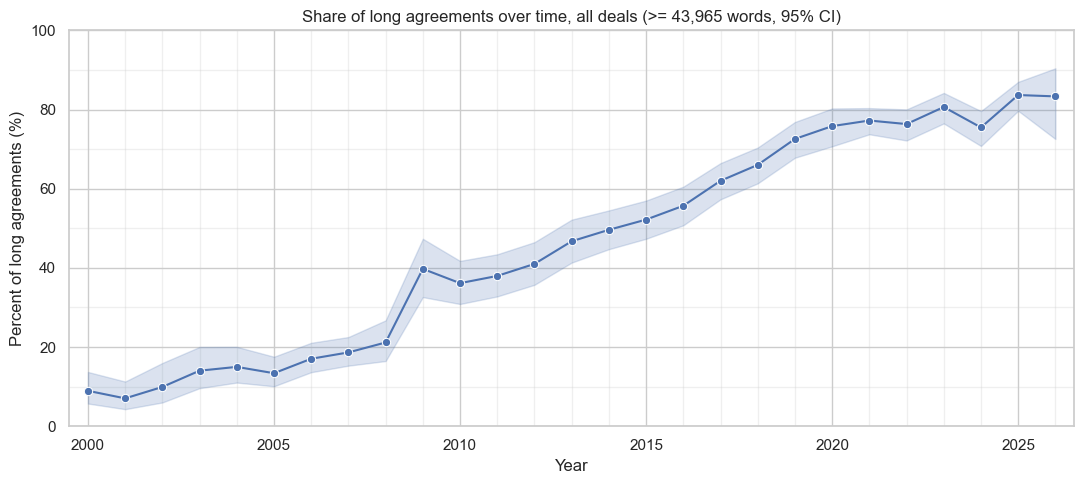

In [13]:
def wilson_ci(k, n, z=1.96):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    lo = np.clip(center - half, 0, 1)
    hi = np.clip(center + half, 0, 1)
    return lo, hi


long_threshold = df["word_count_total_no_sig"].median()
all_df = df.assign(
    is_long_agreement=lambda d: d["word_count_total_no_sig"] >= long_threshold
)

plot_df = (
    all_df.groupby("year", as_index=False)
          .agg(k=("is_long_agreement", "sum"), n=("is_long_agreement", "size"))
          .sort_values("year")
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="pct", marker="o", color="C0")

ax = plt.gca()
ax.fill_between(
    plot_df["year"].to_numpy(),
    plot_df["lo"].to_numpy(),
    plot_df["hi"].to_numpy(),
    alpha=0.2,
    color="C0",
)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Percent of long agreements (%)")
ax.set_title(
    f"Share of long agreements over time, all deals (>= {long_threshold:,.0f} words, 95% CI)"
)
ax.set_ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)
plt.tight_layout()
plt.show()



#### 2. Share of long agreements over time (merger agreements only)


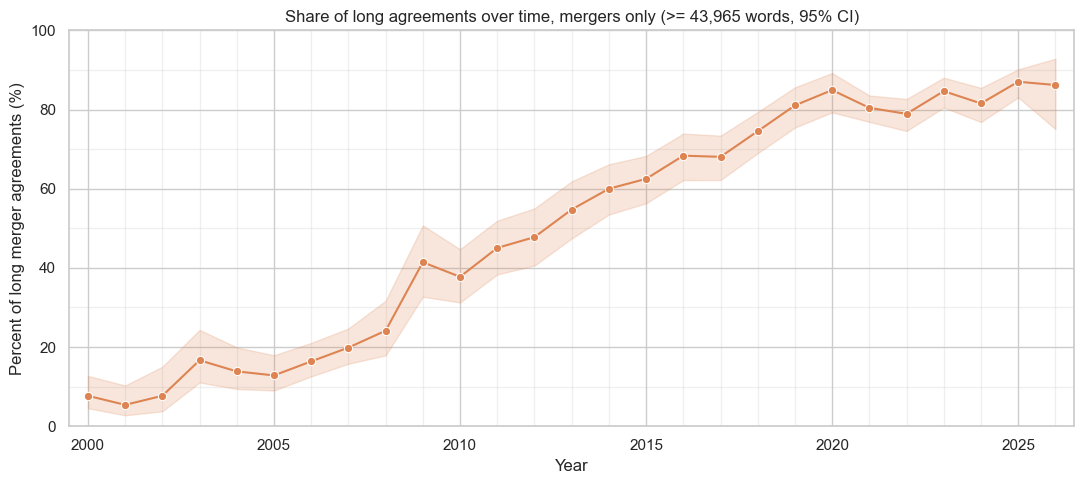

In [14]:
merger_df = df[df["deal_type"] == "Merger"].copy()
if merger_df.empty:
    raise RuntimeError("No merger agreements found in this sample.")

merger_df["is_long_agreement"] = merger_df["word_count_total_no_sig"] >= long_threshold

plot_df = (
    merger_df.groupby("year", as_index=False)
             .agg(k=("is_long_agreement", "sum"), n=("is_long_agreement", "size"))
             .sort_values("year")
)

lo, hi = wilson_ci(plot_df["k"], plot_df["n"])
plot_df["pct"] = (plot_df["k"] / plot_df["n"]) * 100
plot_df["lo"] = lo * 100
plot_df["hi"] = hi * 100

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="pct", marker="o", color="C1")

ax = plt.gca()
ax.fill_between(
    plot_df["year"].to_numpy(),
    plot_df["lo"].to_numpy(),
    plot_df["hi"].to_numpy(),
    alpha=0.2,
    color="C1",
)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Percent of long merger agreements (%)")
ax.set_title(
    f"Share of long agreements over time, mergers only (>= {long_threshold:,.0f} words, 95% CI)"
)
ax.set_ylim(0, 100)
x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)

ax.yaxis.set_major_locator(MultipleLocator(20))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)
plt.tight_layout()
plt.show()



#### 3. Absolute length of agreements over time (merger agreements only)


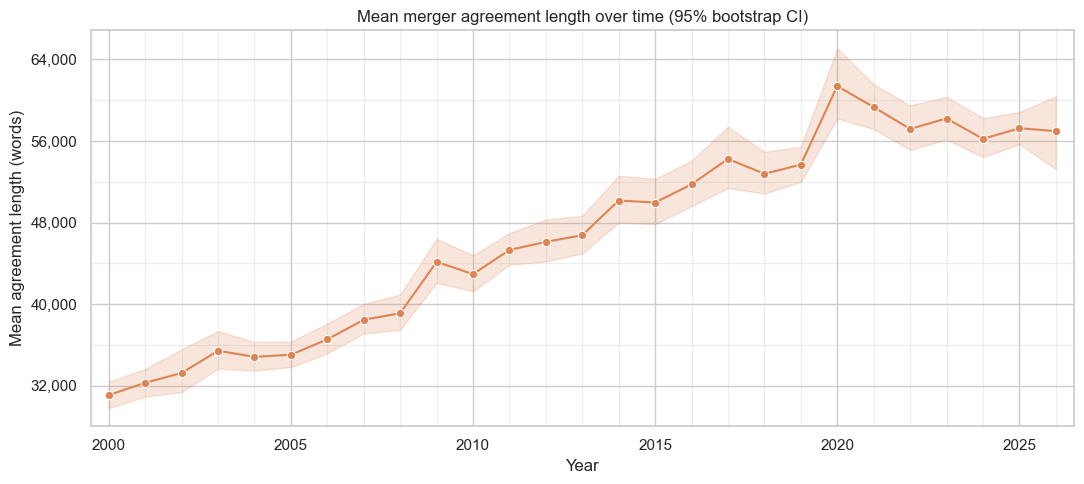

In [15]:
# mergers only
merger_df = df[df["deal_type"] == "Merger"].copy()
merger_df = merger_df.dropna(subset=["year", "word_count_total_no_sig"])
if merger_df.empty:
    raise RuntimeError("No merger agreements found in this sample.")

merger_df["year"] = merger_df["year"].astype(int)

# yearly mean length + 95% bootstrap CI
def boot_mean_ci(x, n_boot=2000, alpha=0.05, rng=None):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return np.nan, np.nan, np.nan
    if x.size == 1:
        return x[0], x[0], x[0]
    rng = np.random.default_rng(42) if rng is None else rng
    idx = rng.integers(0, x.size, size=(n_boot, x.size))
    means = x[idx].mean(axis=1)
    return x.mean(), np.quantile(means, alpha / 2), np.quantile(means, 1 - alpha / 2)

rng = np.random.default_rng(42)
rows = []
for year, g in merger_df.groupby("year"):
    mean_w, lo, hi = boot_mean_ci(g["word_count_total_no_sig"].to_numpy(), rng=rng)
    rows.append({"year": year, "mean_words": mean_w, "lo": lo, "hi": hi, "n": len(g)})

plot_df = pd.DataFrame(rows).sort_values("year")

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="mean_words", marker="o", color="C1")

ax = plt.gca()
ax.fill_between(
    plot_df["year"].to_numpy(),
    plot_df["lo"].to_numpy(),
    plot_df["hi"].to_numpy(),
    alpha=0.2,
    color="C1",
)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Mean agreement length (words)")
ax.set_title("Mean merger agreement length over time (95% bootstrap CI)")

x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(nbins=6))
ax.yaxis.set_minor_locator(plt.matplotlib.ticker.AutoMinorLocator(2))

ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()

#### 4. Page type composition over time


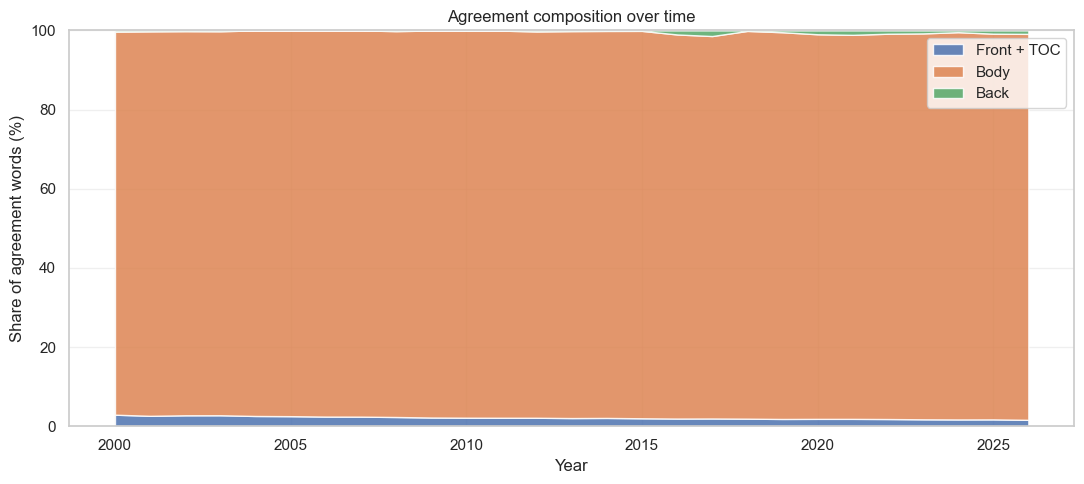

In [16]:
component_by_year = (
    df.groupby("year", as_index=False)
      .agg(
          front_toc=("word_count_front_toc", "median"),
          body=("word_count_body", "median"),
          back=("word_count_back", "median"),
      )
      .sort_values("year")
)
component_total = component_by_year[["front_toc", "body", "back"]].sum(axis=1)
component_total = component_total.replace(0, np.nan)

component_by_year["front_toc_pct"] = (component_by_year["front_toc"] / component_total) * 100
component_by_year["body_pct"] = (component_by_year["body"] / component_total) * 100
component_by_year["back_pct"] = (component_by_year["back"] / component_total) * 100

plt.figure(figsize=(11, 5))
plt.stackplot(
    component_by_year["year"],
    component_by_year["front_toc_pct"],
    component_by_year["body_pct"],
    component_by_year["back_pct"],
    labels=["Front + TOC", "Body", "Back"],
    alpha=0.85,
)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Share of agreement words (%)")
ax.set_ylim(0, 100)
ax.set_title("Agreement composition over time")
ax.grid(True, axis="both", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


#### 5. Agreement length distribution by deal type


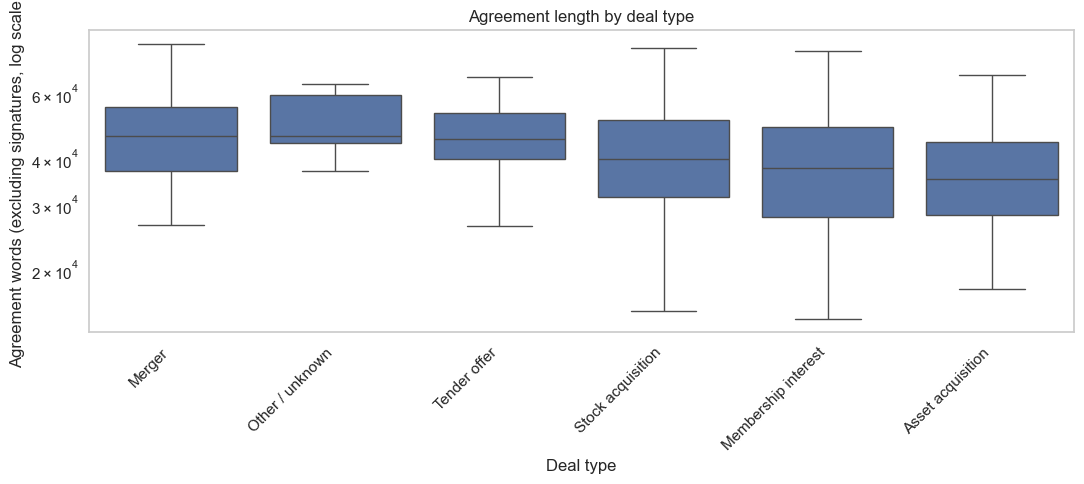

In [17]:
plot_df = df.dropna(subset=["deal_type", "word_count_total_no_sig"]).copy()
order = (
    plot_df.groupby("deal_type")["word_count_total_no_sig"]
           .median()
           .sort_values(ascending=False)
           .index
           .tolist()
)

plt.figure(figsize=(11, 5))
ax = sns.boxplot(
    data=plot_df,
    x="deal_type",
    y="word_count_total_no_sig",
    order=order,
    showfliers=False,
    whis=(5, 95),
)
ax.set_yscale("log")
ax.set_xlabel("Deal type")
ax.set_ylabel("Agreement words (excluding signatures, log scale)")
ax.set_title("Agreement length by deal type")
ax.grid(True, axis="y", which="major", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Section Analysis

#### 1. Sections per agreements


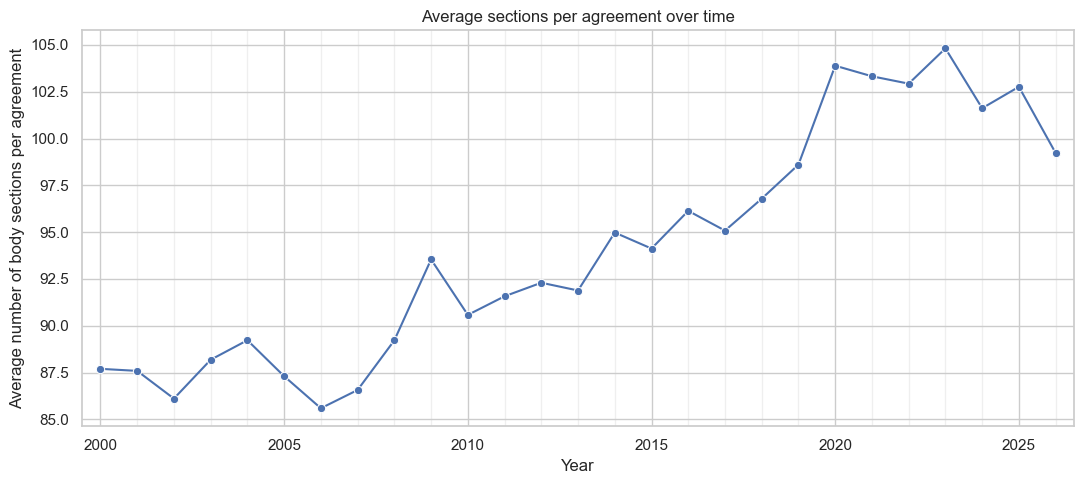

In [18]:
section_df = df.dropna(subset=["year", "section_count_body"]).copy()
section_df["year"] = section_df["year"].astype(int)

plot_df = (
    section_df.groupby("year", as_index=False)
              .agg(
                  avg_sections_per_agreement=("section_count_body", "mean"),
                  n_agreements=("agreement_uuid", "nunique"),
              )
              .sort_values("year")
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="avg_sections_per_agreement", marker="o", color="C0")

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.1f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Average number of body sections per agreement")
ax.set_title("Average sections per agreement over time")

x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)

plt.tight_layout()
plt.show()


#### 2. Words per section


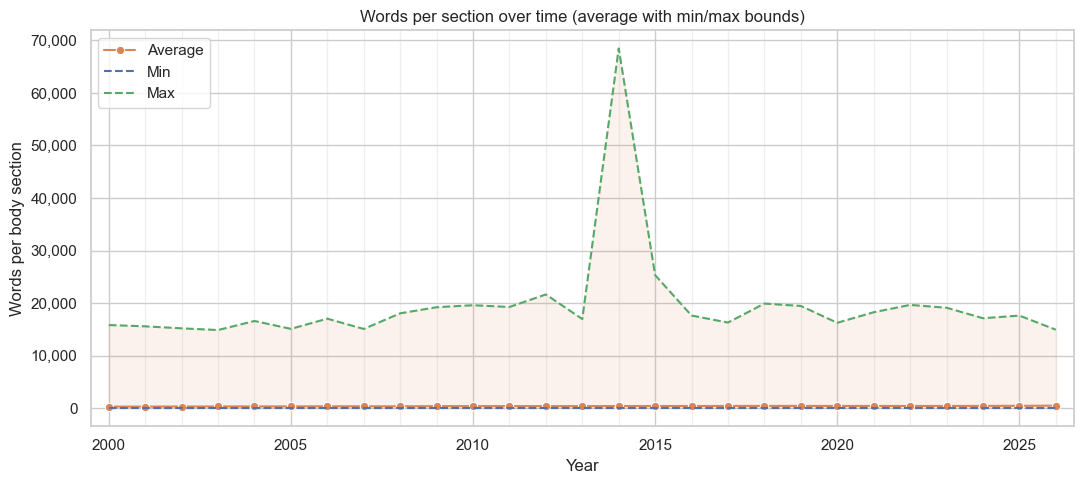

In [19]:
wps_df = df.dropna(subset=["year", "section_count_body"]).copy()
wps_df = wps_df[wps_df["section_count_body"] > 0].copy()
wps_df["year"] = wps_df["year"].astype(int)

rows = []
for year, g in wps_df.groupby("year"):
    section_total = g["section_count_body"].sum()
    if section_total <= 0:
        continue

    weighted_avg_words = float((g["avg_words_per_section_body"] * g["section_count_body"]).sum() / section_total)
    year_min_words = int(g["min_words_per_section_body"].min())
    year_max_words = int(g["max_words_per_section_body"].max())

    rows.append(
        {
            "year": int(year),
            "avg_words_per_section": weighted_avg_words,
            "min_words_per_section": year_min_words,
            "max_words_per_section": year_max_words,
        }
    )

plot_df = pd.DataFrame(rows).sort_values("year")
if plot_df.empty:
    raise RuntimeError("No section-level word statistics available for plotting.")

plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="year", y="avg_words_per_section", marker="o", color="C1", label="Average")
sns.lineplot(data=plot_df, x="year", y="min_words_per_section", color="C0", linestyle="--", label="Min")
sns.lineplot(data=plot_df, x="year", y="max_words_per_section", color="C2", linestyle="--", label="Max")

ax = plt.gca()
ax.fill_between(
    plot_df["year"].to_numpy(),
    plot_df["min_words_per_section"].to_numpy(),
    plot_df["max_words_per_section"].to_numpy(),
    alpha=0.1,
    color="C1",
)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Words per body section")
ax.set_title("Words per section over time (average with min/max bounds)")

x_min, x_max = plot_df["year"].min(), plot_df["year"].max()
ax.set_xlim(x_min - 0.5, x_max + 0.5)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="both", alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


### What's driving length?

Work in progress...

#### Download

In [22]:
# Extraction path:
# - Use GET /v1/agreements with deal_type=merger and include_xml=true
# - The full agreement XML already carries clause taxonomy on <section standardId="...">
# - standardId may be either a single ID string or a JSON-serialized list of IDs
# - This stays on a single endpoint and parses standardId the same way the API parses section-level IDs

MERGER_CLAUSE_TOP_N = 10
MERGER_CLAUSE_OTHER_LABEL = "Other / unlabeled"


def flatten_taxonomy_labels(tree: dict[str, object]) -> dict[str, str]:
    labels: dict[str, str] = {}

    def walk(children: dict[str, object]) -> None:
        for label, raw_node in children.items():
            if not isinstance(raw_node, dict):
                continue

            standard_id = raw_node.get("id")
            if isinstance(standard_id, str) and standard_id:
                labels[standard_id] = label

            raw_children = raw_node.get("children")
            if isinstance(raw_children, dict):
                walk(raw_children)

    walk(tree)
    return labels


def parse_standard_ids_attr(raw: str | None) -> list[str]:
    if raw is None:
        return []

    serialized = raw.strip()
    if not serialized:
        return []

    try:
        parsed = json.loads(serialized)
    except json.JSONDecodeError:
        return [serialized]

    if isinstance(parsed, str):
        return [parsed]
    if not isinstance(parsed, list) or not all(isinstance(item, str) for item in parsed):
        raise ValueError("section standardId must be a string or JSON list of strings.")

    deduped_ids: list[str] = []
    seen: set[str] = set()
    for item in parsed:
        if item in seen:
            continue
        seen.add(item)
        deduped_ids.append(item)
    return deduped_ids


def section_clause_word_totals(xml: str) -> tuple[dict[str, float], float]:
    root = ET.fromstring(xml)

    clause_words: dict[str, float] = {}
    unlabeled_words = 0.0

    for elem in root.iter():
        if local_name(elem.tag) != "section":
            continue

        words = count_words_in_element(elem)
        if words == 0:
            continue

        standard_ids = parse_standard_ids_attr(elem.attrib.get("standardId"))
        if not standard_ids:
            unlabeled_words += words
            continue

        # Split section words evenly across multiple clause labels so yearly shares still sum to 100%
        words_per_label = words / len(standard_ids)
        for standard_id in standard_ids:
            clause_words[standard_id] = clause_words.get(standard_id, 0.0) + words_per_label

    return clause_words, unlabeled_words


taxonomy_r = session.get(f"{API_BASE_URL}/v1/taxonomy", timeout=30)
taxonomy_r.raise_for_status()
clause_label_by_id = flatten_taxonomy_labels(taxonomy_r.json())

page_size = 100
request_pause_s = 0.25

merger_agreements = []
merger_clause_rows = []
cursor = None
batch_num = 0
start_time = time.time()

while True:
    params = {
        "page_size": page_size,
        "include_xml": True,
        "deal_type": "merger",
    }
    if cursor:
        params["cursor"] = cursor

    r = session.get(f"{API_BASE_URL}/v1/agreements", params=params, timeout=60)
    r.raise_for_status()
    payload = r.json()

    batch = payload.get("results", [])
    batch_num += 1

    for agreement in batch:
        agreement_uuid = agreement.get("agreement_uuid")
        year = agreement.get("year")
        xml = agreement.get("xml")

        if not isinstance(agreement_uuid, str) or not agreement_uuid:
            raise RuntimeError("Invalid agreements payload: missing agreement_uuid.")
        if not isinstance(xml, str) or not xml:
            raise RuntimeError(
                "Invalid agreements payload: xml is missing. Ensure include_xml=true and authenticated access."
            )
        if year is None:
            continue

        clause_words, unlabeled_words = section_clause_word_totals(xml)
        merger_agreements.append(
            {
                "agreement_uuid": agreement_uuid,
                "year": int(year),
                "unlabeled_words": unlabeled_words,
            }
        )

        for standard_id, words in clause_words.items():
            merger_clause_rows.append(
                {
                    "agreement_uuid": agreement_uuid,
                    "year": int(year),
                    "standard_id": standard_id,
                    "words": words,
                }
            )

    if batch_num % 10 == 0 or not payload.get("has_next"):
        elapsed = time.time() - start_time
        print(
            f"Progress: batch {batch_num} | batch_size={len(batch)} | merger agreements={len(merger_agreements)} | elapsed={elapsed:.1f}s"
        )

    if not payload.get("has_next"):
        break

    next_cursor = payload.get("next_cursor")
    if not isinstance(next_cursor, str) or not next_cursor:
        raise RuntimeError("Invalid agreements payload: has_next=true but next_cursor missing.")

    cursor = next_cursor
    time.sleep(request_pause_s)

elapsed_total = time.time() - start_time
print(f"Returned merger agreements: {len(merger_agreements)}")
print(f"Access tier: {payload.get('access', {}).get('tier')}")
print(f"Total download time: {elapsed_total:.1f}s")

if not merger_agreements:
    raise RuntimeError("No merger agreements returned by /v1/agreements.")
if not merger_clause_rows:
    raise RuntimeError("No section standardId values found in merger agreement XML.")

#### Analysis

In [23]:
merger_agreements_df = pd.DataFrame(merger_agreements)
merger_clause_df = pd.DataFrame(merger_clause_rows)

agreement_index = (
    merger_agreements_df.drop_duplicates(subset=["agreement_uuid", "year"])
                       .set_index(["agreement_uuid", "year"])
                       .sort_index()
)

clause_wide = merger_clause_df.pivot_table(
    index=["agreement_uuid", "year"],
    columns="standard_id",
    values="words",
    aggfunc="sum",
    fill_value=0,
)
clause_wide = clause_wide.reindex(agreement_index.index, fill_value=0)

# Treat clause-type absence as zero words at the agreement level before taking yearly medians
top_standard_ids = (
    clause_wide.median(axis=0)
              .sort_values(ascending=False)
              .head(MERGER_CLAUSE_TOP_N)
              .index
              .tolist()
)

plot_wide = clause_wide[top_standard_ids].copy()
plot_wide[MERGER_CLAUSE_OTHER_LABEL] = (
    clause_wide.drop(columns=top_standard_ids, errors="ignore").sum(axis=1)
    + agreement_index["unlabeled_words"]
)

yearly_median_words = plot_wide.groupby(level="year").median().sort_index()
yearly_median_shares = (
    yearly_median_words.div(yearly_median_words.sum(axis=1).replace(0, np.nan), axis=0) * 100
)

column_labels = {
    standard_id: clause_label_by_id.get(standard_id, standard_id)
    for standard_id in top_standard_ids
}
column_labels[MERGER_CLAUSE_OTHER_LABEL] = MERGER_CLAUSE_OTHER_LABEL

plot_df = yearly_median_shares.rename(columns=column_labels)
plot_order = [column_labels[standard_id] for standard_id in top_standard_ids] + [MERGER_CLAUSE_OTHER_LABEL]
plot_df = plot_df[plot_order]

colors = sns.color_palette("tab20", n_colors=len(plot_df.columns))

plt.figure(figsize=(12, 6))
plt.stackplot(
    plot_df.index,
    *[plot_df[column].to_numpy() for column in plot_df.columns],
    labels=plot_df.columns,
    colors=colors,
    alpha=0.9,
)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Share of median agreement clause words (%)")
ax.set_ylim(0, 100)
ax.set_title(
    f"Merger agreement clause-type composition over time (median words per agreement, top {MERGER_CLAUSE_TOP_N})"
)
ax.grid(True, axis="both", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

plot_df.tail()